In [119]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math

import statsmodels.api as sm

In [120]:
raw_car_prices_df = pd.read_csv("Car_price_prediction.csv",delimiter=',')
print(raw_car_prices_df.columns)
raw_car_prices_df.head()

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='object')


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [121]:
# Columns we will use for the analysis
columns_to_use = ['Price', 'Manufacturer', 'Prod. year', 'Category', 'Fuel type', 'Cylinders', 'Mileage', 'Airbags']
car_prices_df = raw_car_prices_df[columns_to_use].copy()
# rename the prod year and fuel type column, remove spaces and put underscore
car_prices_df = car_prices_df.rename(columns={'Prod. year': 'production_year', 'Fuel type': 'fuel_type'})
# covert all the column names to lowercase.
car_prices_df.columns = [c.lower() for c in car_prices_df.columns]
print(car_prices_df.columns)


Index(['price', 'manufacturer', 'production_year', 'category', 'fuel_type',
       'cylinders', 'mileage', 'airbags'],
      dtype='object')


In [122]:
car_prices_df['mileage'].head()

0    186005 km
1    192000 km
2    200000 km
3    168966 km
4     91901 km
Name: mileage, dtype: object

In [123]:
# remove the km in the mileage column and remove extra white spaces before and after each value
car_prices_df['mileage'] = car_prices_df['mileage'].str.replace('km', '').str.strip()
# if less than 500 examples/datapoints for a manufacturer remove it from the data for now.
car_prices_df['manufacturer'] = car_prices_df['manufacturer'].str.lower()

In [124]:
car_prices_df['manufacturer'].value_counts()

manufacturer
hyundai          3769
toyota           3662
mercedes-benz    2076
ford             1111
chevrolet        1069
                 ... 
tesla               1
pontiac             1
saturn              1
aston martin        1
greatwall           1
Name: count, Length: 65, dtype: int64

In [125]:
car_prices_df.dtypes

price                int64
manufacturer        object
production_year      int64
category            object
fuel_type           object
cylinders          float64
mileage             object
airbags              int64
dtype: object

In [126]:
manufaturer_frequency_table = car_prices_df['manufacturer'].value_counts()
keep_manufacturers = manufaturer_frequency_table[manufaturer_frequency_table > 500]
car_prices_df = car_prices_df[car_prices_df['manufacturer'].isin(keep_manufacturers.index)]

# keep only cars whose production year is > 2000
car_prices_df = car_prices_df[(car_prices_df['production_year'] > 2000) & (car_prices_df['production_year'] < 2020)].reset_index(drop=True).copy()
car_prices_df = car_prices_df.astype({'mileage':float})

In [127]:
print(car_prices_df.shape)
car_prices_df.head()

(15112, 8)


,price,manufacturer,production_year,category,fuel_type,cylinders,mileage,airbags
0,13328,lexus,2010,Jeep,Hybrid,6.0,186005.0,12
1,16621,chevrolet,2011,Jeep,Petrol,6.0,192000.0,8
2,8467,honda,2006,Hatchback,Petrol,4.0,200000.0,2
3,3607,ford,2011,Jeep,Hybrid,4.0,168966.0,0
4,11726,honda,2014,Hatchback,Petrol,4.0,91901.0,4


manufacturer
hyundai          3744
toyota           3628
mercedes-benz    1757
chevrolet        1066
ford              985
lexus             976
honda             935
bmw               921
nissan            631
volkswagen        469
Name: count, dtype: int64


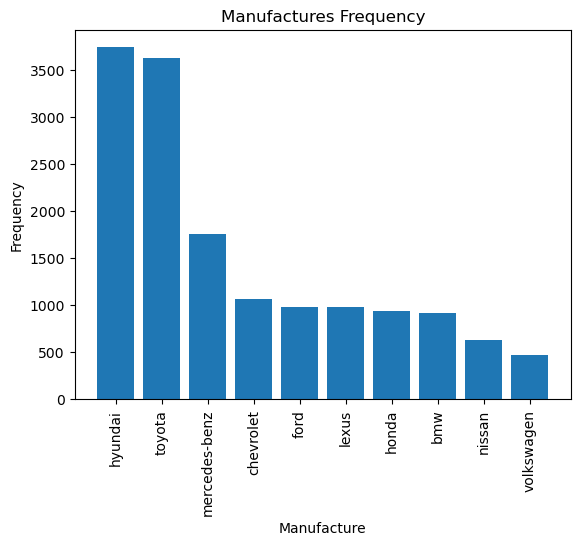

In [128]:
# Exploratory Data Analysis (EDA)
frequency_table = car_prices_df['manufacturer'].value_counts()

print(frequency_table)

# create a bar chart
plt.bar(frequency_table.index, frequency_table.values)

# set the chart title and axes labels
plt.title('Manufactures Frequency')
plt.xlabel('Manufacture')
plt.ylabel('Frequency')

# rotate x-axis lables by 90 degrees
plt.xticks(rotation=90)

#display the chart
plt.show()

category
Sedan          7171
Jeep           4024
Hatchback      2422
Minivan         543
Coupe           369
Universal       237
Microbus        200
Goods wagon      93
Pickup           30
Cabriolet        23
Name: count, dtype: int64


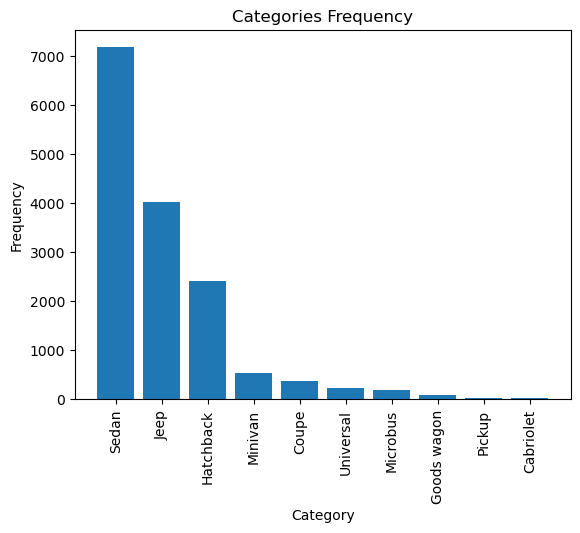

In [129]:
frequency_table = car_prices_df['category'].value_counts()

print(frequency_table)

#Create a bar chart
plt.bar(frequency_table.index, frequency_table.values)

# set the chart title and axes lables
plt.title('Categories Frequency')
plt.xlabel('Category')
plt.ylabel('Frequency')

# Rotate x-axis lables by 90 degrees
plt.xticks(rotation=90)

# Display the chart
plt.show()

fuel_type
Petrol            7508
Hybrid            3482
Diesel            3092
LPG                800
CNG                144
Plug-in Hybrid      85
Hydrogen             1
Name: count, dtype: int64


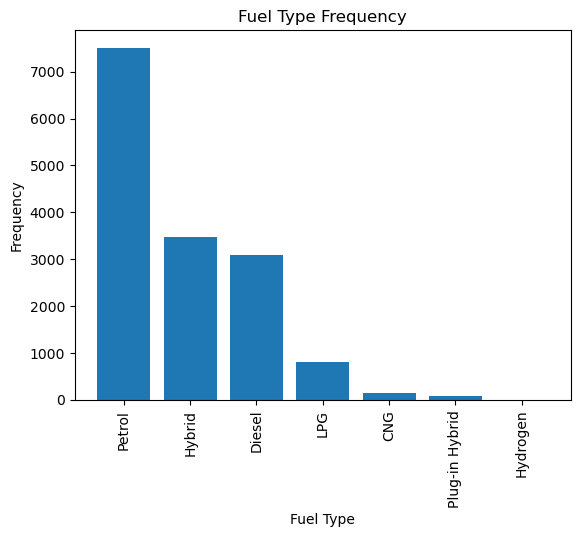

In [130]:
frequency_table = car_prices_df['fuel_type'].value_counts()

print(frequency_table)
# Create a bar chart
plt.bar(frequency_table.index, frequency_table.values)

# set the chart title and axes lables
plt.title('Fuel Type Frequency')
plt.xlabel('Fuel Type')
plt.ylabel('Frequency')

# rotate x-axis lables by 90 degrees
plt.xticks(rotation=90)

#Display the chart
plt.show()

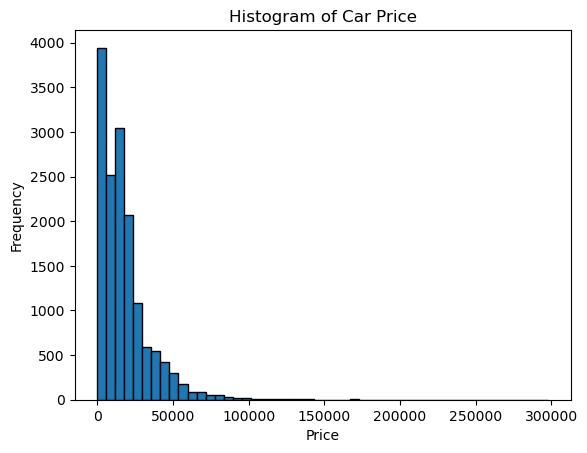

In [131]:
# Create a histogram based on the price column
plt.hist(car_prices_df['price'], bins=50, edgecolor='black')

# Set the plot lables and title
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of Car Price')

# Display the histogram
plt.show()

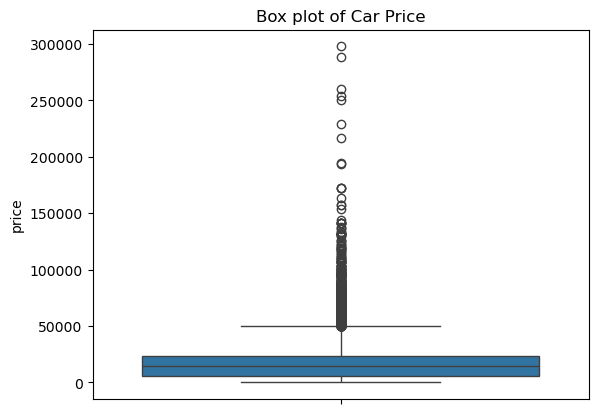

In [132]:
sns.boxplot(y=car_prices_df['price'])
plt.title('Box plot of Car Price')
plt.show()

In [133]:
car_prices_df['price'].describe()

count     15112.000000
mean      17691.736435
std       18230.150181
min           1.000000
25%        5331.000000
50%       14113.000000
75%       23138.000000
max      297930.000000
Name: price, dtype: float64

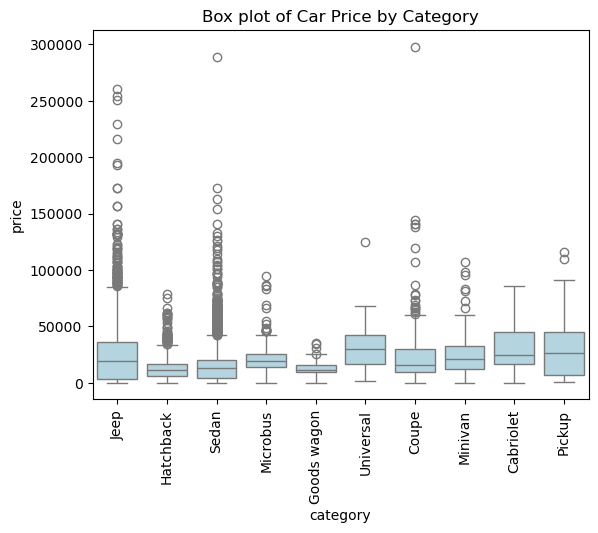

In [134]:
sns.boxplot(data=car_prices_df, x="category", y="price", color='lightblue')
plt.xticks(rotation=90)
plt.title('Box plot of Car Price by Category')
plt.show()

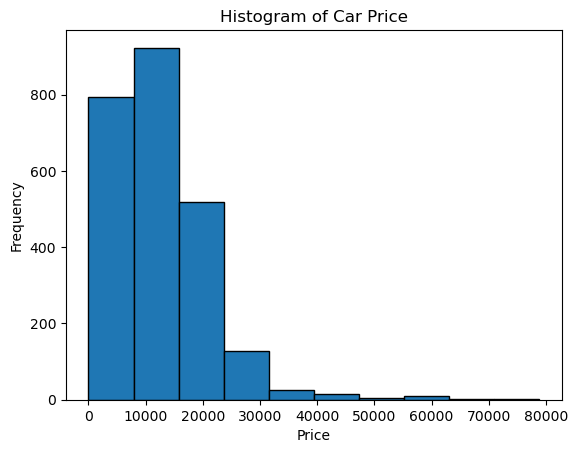

In [135]:
# create a histogram based on the price column
plt.hist(car_prices_df[car_prices_df['category'] == 'Hatchback']['price'], edgecolor='black')

#Set the plot labels and title
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of Car Price')

# Display the histogram
plt.show()

543


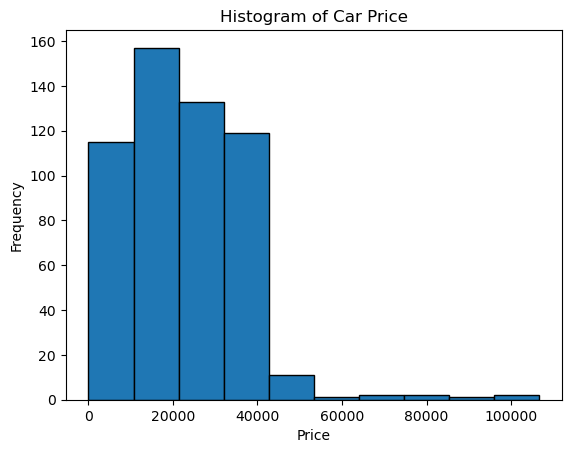

In [136]:
print((car_prices_df['category']=='Minivan').sum())
#Create a histogram based on the price column
plt.hist(car_prices_df[car_prices_df['category']=='Minivan']['price'],edgecolor='black')

# Set the plot labels and title
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of Car Price')

#Display the histogram
plt.show()
      

23


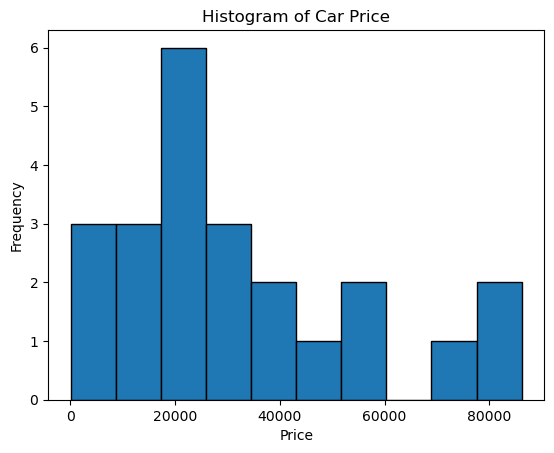

In [137]:
print((car_prices_df['category']=='Cabriolet').sum())
# Create a histogram based on the Price column
plt.hist(car_prices_df[car_prices_df['category']=='Cabriolet']['price'], edgecolor='black')

# Set the plot labels and title
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of Car Price')

# Display the histogram
plt.show()

In [138]:
car_prices_df.describe()

,price,production_year,cylinders,mileage,airbags
count,15112.000000,15112.000000,15112.000000,1.511200e+04,15112.000000
mean,17691.736435,2012.064915,4.606935,8.324967e+05,6.936805
std,18230.150181,3.848199,1.211672,3.316859e+07,4.340960
min,1.000000,2001.000000,1.000000,0.000000e+00,0.000000
25%,5331.000000,2010.000000,4.000000,7.364600e+04,4.000000
50%,14113.000000,2013.000000,4.000000,1.274160e+05,6.000000
75%,23138.000000,2015.000000,4.000000,1.875000e+05,12.000000
max,297930.000000,2019.000000,16.000000,2.147484e+09,16.000000


In [139]:
car_prices_df.corr(numeric_only=True)

,price,production_year,cylinders,mileage,airbags
price,1.000000,0.273547,0.105825,-0.008021,-0.069732
production_year,0.273547,1.000000,-0.170673,-0.036231,0.110047
cylinders,0.105825,-0.170673,1.000000,0.003040,0.162738
mileage,-0.008021,-0.036231,0.003040,1.000000,-0.008405
airbags,-0.069732,0.110047,0.162738,-0.008405,1.000000


In [140]:
car_prices_df[car_prices_df['manufacturer']=='hyundai'].corr(numeric_only=True)

,price,production_year,cylinders,mileage,airbags
price,1.000000,0.436841,-0.043394,-0.301984,-0.222962
production_year,0.436841,1.000000,-0.022638,-0.019369,0.101235
cylinders,-0.043394,-0.022638,1.000000,-0.035591,0.142553
mileage,-0.301984,-0.019369,-0.035591,1.000000,-0.102811
airbags,-0.222962,0.101235,0.142553,-0.102811,1.000000


In [141]:
car_prices_df[car_prices_df['manufacturer']=='bmw'].corr(numeric_only=True)

,price,production_year,cylinders,mileage,airbags
price,1.000000,0.307049,0.099929,-0.013498,0.261283
production_year,0.307049,1.000000,-0.139859,-0.027208,0.140561
cylinders,0.099929,-0.139859,1.000000,0.000470,0.025789
mileage,-0.013498,-0.027208,0.000470,1.000000,0.053762
airbags,0.261283,0.140561,0.025789,0.053762,1.000000


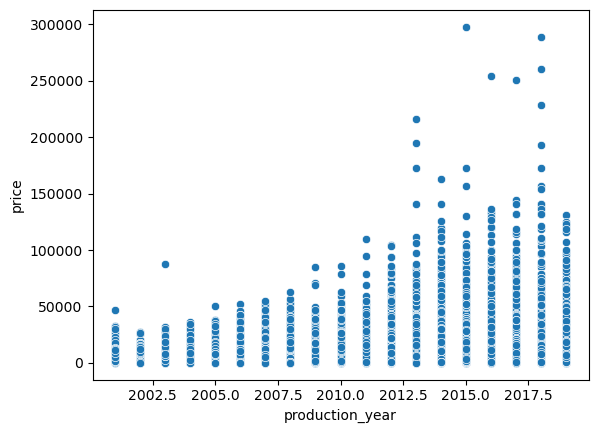

In [142]:
sns.scatterplot(data=car_prices_df, x="production_year", y="price")
plt.show()

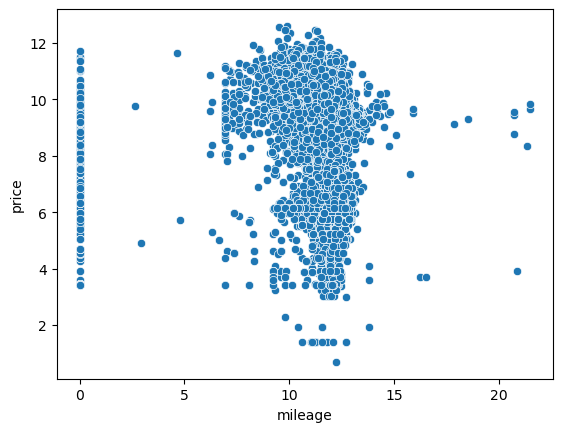

In [143]:
sns.scatterplot(
    x=np.log1p(car_prices_df['mileage']),
    y=np.log1p(car_prices_df['price'])
)
plt.show()


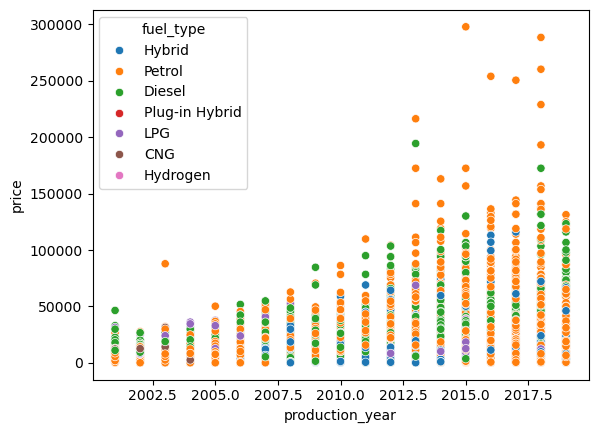

In [144]:
sns.scatterplot(data=car_prices_df, x="production_year", y="price", hue="fuel_type")
plt.show()

In [145]:
car_prices_df.columns

Index(['price', 'manufacturer', 'production_year', 'category', 'fuel_type',
       'cylinders', 'mileage', 'airbags'],
      dtype='object')

In [146]:
car_prices_df.dtypes

price                int64
manufacturer        object
production_year      int64
category            object
fuel_type           object
cylinders          float64
mileage            float64
airbags              int64
dtype: object

In [147]:
# Explained using the point.
categorical_columns = ['manufacturer', 'category', 'fuel_type']
numerical_columns = ['production_year', 'cylinders', 'airbags']
# Extract features (X) and target varible (y)
X = car_prices_df[categorical_columns+numerical_columns]
y = car_prices_df['price']

In [148]:
X.head()

,manufacturer,category,fuel_type,production_year,cylinders,airbags
0,lexus,Jeep,Hybrid,2010,6.0,12
1,chevrolet,Jeep,Petrol,2011,6.0,8
2,honda,Hatchback,Petrol,2006,4.0,2
3,ford,Jeep,Hybrid,2011,4.0,0
4,honda,Hatchback,Petrol,2014,4.0,4


In [149]:
car_prices_df[['fuel_type']].value_counts()

fuel_type     
Petrol            7508
Hybrid            3482
Diesel            3092
LPG                800
CNG                144
Plug-in Hybrid      85
Hydrogen             1
Name: count, dtype: int64

In [150]:
enc = OneHotEncoder(drop='first', sparse_output=False)
enc_output = enc.fit_transform(car_prices_df[['fuel_type']])
pd.DataFrame(enc_output, columns=enc.get_feature_names_out())

,fuel_type_Diesel,fuel_type_Hybrid,fuel_type_Hydrogen,fuel_type_LPG,fuel_type_Petrol,fuel_type_Plug-in Hybrid
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...
15107,1.0,0.0,0.0,0.0,0.0,0.0
15108,0.0,0.0,0.0,0.0,1.0,0.0
15109,1.0,0.0,0.0,0.0,0.0,0.0
15110,1.0,0.0,0.0,0.0,0.0,0.0


In [151]:
# Create a column tranformer for one-hot encoding

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_columns)
    ],
    remainder='passthrough'
)

# apply one-hot encoding to x
X = preprocessor.fit_transform(X)

pd.DataFrame(X, columns=preprocessor.get_feature_names_out()).head()

,cat__manufacturer_chevrolet,cat__manufacturer_ford,cat__manufacturer_honda,cat__manufacturer_hyundai,cat__manufacturer_lexus,cat__manufacturer_mercedes-benz,cat__manufacturer_nissan,cat__manufacturer_toyota,cat__manufacturer_volkswagen,cat__category_Coupe,...,cat__category_Universal,cat__fuel_type_Diesel,cat__fuel_type_Hybrid,cat__fuel_type_Hydrogen,cat__fuel_type_LPG,cat__fuel_type_Petrol,cat__fuel_type_Plug-in Hybrid,remainder__production_year,remainder__cylinders,remainder__airbags
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2010.0,6.0,12.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2011.0,6.0,8.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2006.0,4.0,2.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2011.0,4.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2014.0,4.0,4.0


In [152]:
# MODEL BUILDING
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [153]:
model = LinearRegression()

# Model training
model.fit(X_train, y_train)

# Make predictions on the training set for futher evaluation
y_train_pred = model.predict(X_train)

y_pred = model.predict(X_test)

# Calculate R-squared (r2)
r2 = r2_score(y_test, y_pred)

# Calculate adjustedr R-squared (adjusted_r2)
n = X_test.shape[0] #number of samples
p = X_test.shape[1] #number of features
adjusted_r2 = 1 - ((1 - r2)*(n - 1) / (n - p - 1))

# Calculate Mean Squared Error (mse)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (rsme)
rmase = math.sqrt(mse)

# Calculate Mean Absolute Error (mae)
mae = mean_absolute_error(y_test, y_pred)

# Print the results
print(f'R-squared (r2): {r2:.2f}')
print(f'Adjusted R-squared (adjusted_r2): {adjusted_r2:.2f}')
print(f'Mean Squared Error (mse): {mse:.2f}')
print(f'Root Mean Squared Error (rmse): {rmse:.2f}')
print(f'Mean Absolute Error (mae): {mae:.2f}')

R-squared (r2): 0.22
Adjusted R-squared (adjusted_r2): 0.21
Mean Squared Error (mse): 238629296.83
Root Mean Squared Error (rmse): 16129.25
Mean Absolute Error (mae): 10807.04


In [154]:
r2_score(y_train, y_train_pred)

0.2113473903301043

In [155]:
def model_fit_and_report(model):

  # Model training
    model.fit(X_train, y_train)
  # Make predictions on the training set for further evaluation
    y_train_pred = model.predict(X_train)

    y_pred = model.predict(X_test)
    # Calculate R-squared (r2)
    r2 = r2_score(y_test, y_pred)

  # Calculate Adjusted  R-squared  (adjusted_r2)
    n = X_test.shape[0] # number of samples
    p = X_test.shape[1] # number of features
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

  # Calculate Mean Squared Error (mse)
    mse = mean_squared_error(y_test, y_pred)

  # Calculate Root Mean Squared Error (rmse)
    rmse = math.sqrt(mse)

  # Calculate Mean Absolute Error (mae)
    mae = mean_absolute_error(y_test, y_pred)

  # Print the results
    print(f'Test R-squared (r2): {r2:.2f}')
    print(f'Test Adjusted R-squared (adjusted_r2):{adjusted_r2:.2f}')
    print(f'Test Mean Squared Error (mse): {mse:.2f}')
    print(f'Test Root Mean Squared Error (rmse): {rmse:.2f}')
    print(f'Test Mean Absolute Error (mae): {mae:.2f}')




In [156]:
# Create a linear regression model
model_fit_and_report(LinearRegression())

Test R-squared (r2): 0.22
Test Adjusted R-squared (adjusted_r2):0.21
Test Mean Squared Error (mse): 238629296.83
Test Root Mean Squared Error (rmse): 15447.63
Test Mean Absolute Error (mae): 10807.04


In [157]:
# Create a linear regression model
model_fit_and_report(Ridge(alpha=0.1))

Test R-squared (r2): 0.22
Test Adjusted R-squared (adjusted_r2):0.21
Test Mean Squared Error (mse): 238641533.51
Test Root Mean Squared Error (rmse): 15448.03
Test Mean Absolute Error (mae): 10807.37


In [158]:
# Create a linear regression model
model_fit_and_report(Lasso(alpha=10.0))

Test R-squared (r2): 0.22
Test Adjusted R-squared (adjusted_r2):0.21
Test Mean Squared Error (mse): 239424461.93
Test Root Mean Squared Error (rmse): 15473.35
Test Mean Absolute Error (mae): 10837.35


In [159]:
model_fit_and_report(ElasticNet(alpha=1.0, l1_ratio=0.5))

Test R-squared (r2): 0.17
Test Adjusted R-squared (adjusted_r2):0.15
Test Mean Squared Error (mse): 256850255.11
Test Root Mean Squared Error (rmse): 16026.55
Test Mean Absolute Error (mae): 11464.72


In [160]:
model_fit_and_report(DecisionTreeRegressor(random_state=42, max_depth=10))

Test R-squared (r2): 0.41
Test Adjusted R-squared (adjusted_r2):0.40
Test Mean Squared Error (mse): 181410227.15
Test Root Mean Squared Error (rmse): 13468.86
Test Mean Absolute Error (mae): 8541.90


In [161]:
X_train_ols = sm.add_constant(pd.DataFrame(X, columns=preprocessor.get_feature_names_out()))
# X_test_ols = sm.add_constant(pd.DataFrame(X.toarray(), columns=preprocessor.get_feature_names_out()))

ols_model = sm.OLS(y, X_train_ols)
ols_result = ols_model.fit()

print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     150.9
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:24:19   Log-Likelihood:            -1.6790e+05
No. Observations:               15112   AIC:                         3.359e+05
Df Residuals:                   15084   BIC:                         3.361e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     